In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(42)

data = {
    'Product_ID': [f'P{i}' for i in range(1001, 1101)],
    
    'Machine': np.random.choice(['M1', 'M2', 'M3', 'M4'], 100),
    
    'Shift': np.random.choice(['Day', 'Night'], 100),
    
    'Temperature': np.random.randint(40, 100, 100),
    
    'Pressure': np.random.randint(10, 50, 100),
    
    'Production_Speed': np.random.randint(100, 500, 100),
    
    'Defect': np.random.choice(['Yes', 'No'], 100, p=[0.3, 0.7])
}

df = pd.DataFrame(data)


df.to_csv("manufacturing_data.csv", index=False)

print("Dataset Created Successfully!")
print(df.head())





Dataset Created Successfully!
  Product_ID Machine  Shift  Temperature  Pressure  Production_Speed Defect
0      P1001      M3    Day           71        13               416     No
1      P1002      M4  Night           78        20               403    Yes
2      P1003      M1  Night           88        26               246    Yes
3      P1004      M3  Night           91        47               103     No
4      P1005      M3  Night           71        33               134     No


In [3]:
print("\n================ DATASET INFO ================\n")
print(df.info())

print("\n================ STATISTICS ================\n")
print(df.describe())

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())


================ DATASET INFO ================

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Product_ID        100 non-null    str  
 1   Machine           100 non-null    str  
 2   Shift             100 non-null    str  
 3   Temperature       100 non-null    int32
 4   Pressure          100 non-null    int32
 5   Production_Speed  100 non-null    int32
 6   Defect            100 non-null    str  
dtypes: int32(3), str(4)
memory usage: 5.7 KB
None

================ STATISTICS ================

       Temperature    Pressure  Production_Speed
count   100.000000  100.000000        100.000000
mean     71.510000   30.640000        296.190000
std      17.438779   11.673608        115.924365
min      40.000000   10.000000        103.000000
25%      60.500000   20.000000        199.500000
50%      71.500000   31.000000        282.500000
75%      88.0

In [4]:
print("\n================ DEFECT COUNT ================\n")
print(df['Defect'].value_counts())



================ DEFECT COUNT ================

Defect
No     69
Yes    31
Name: count, dtype: int64


In [5]:
print("\n================ DATASET INFO ================\n")
print(df.info())

print("\n================ STATISTICS ================\n")
print(df.describe())

print("\n================ MISSING VALUES ================\n")
print(df.isnull().sum())



================ DATASET INFO ================

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Product_ID        100 non-null    str  
 1   Machine           100 non-null    str  
 2   Shift             100 non-null    str  
 3   Temperature       100 non-null    int32
 4   Pressure          100 non-null    int32
 5   Production_Speed  100 non-null    int32
 6   Defect            100 non-null    str  
dtypes: int32(3), str(4)
memory usage: 5.7 KB
None

================ STATISTICS ================

       Temperature    Pressure  Production_Speed
count   100.000000  100.000000        100.000000
mean     71.510000   30.640000        296.190000
std      17.438779   11.673608        115.924365
min      40.000000   10.000000        103.000000
25%      60.500000   20.000000        199.500000
50%      71.500000   31.000000        282.500000
75%      88.0

In [6]:
sns.set_style("whitegrid")


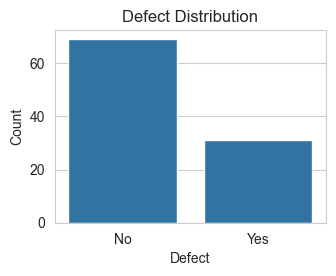

In [7]:
plt.figure(figsize=(3.5,2.5))

sns.countplot(x='Defect', data=df)

plt.title("Defect Distribution")
plt.xlabel("Defect")
plt.ylabel("Count")

plt.show()


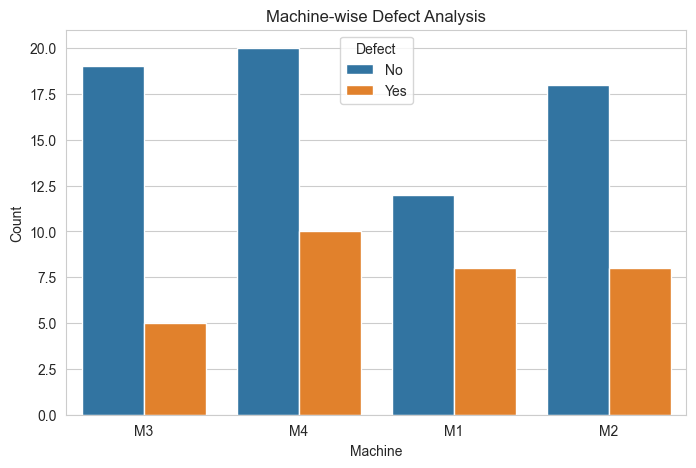

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x='Machine', hue='Defect', data=df)

plt.title("Machine-wise Defect Analysis")
plt.xlabel("Machine")
plt.ylabel("Count")

plt.show()


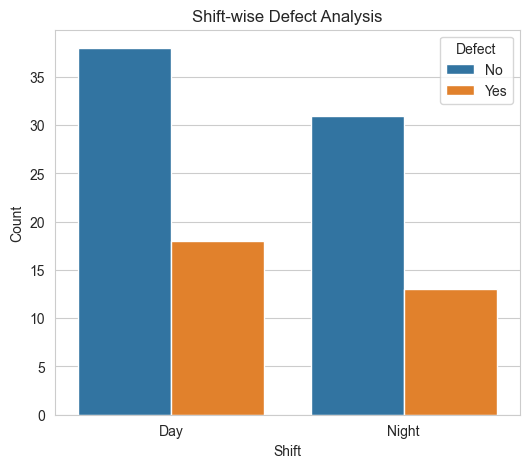

In [9]:
plt.figure(figsize=(6,5))

sns.countplot(x='Shift', hue='Defect', data=df)

plt.title("Shift-wise Defect Analysis")
plt.xlabel("Shift")
plt.ylabel("Count")

plt.show()

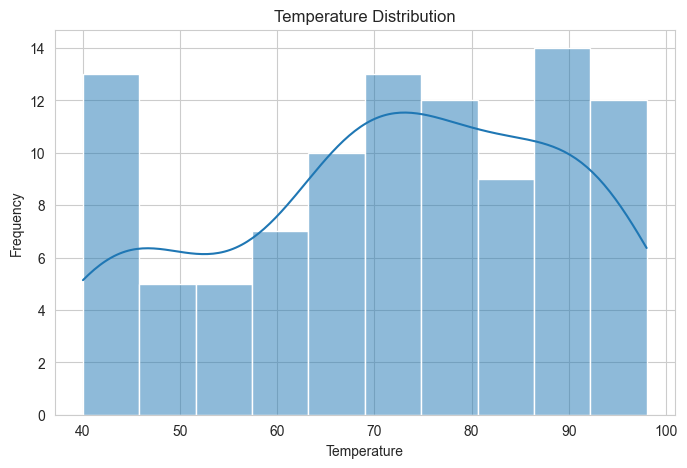

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(df['Temperature'], bins=10, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

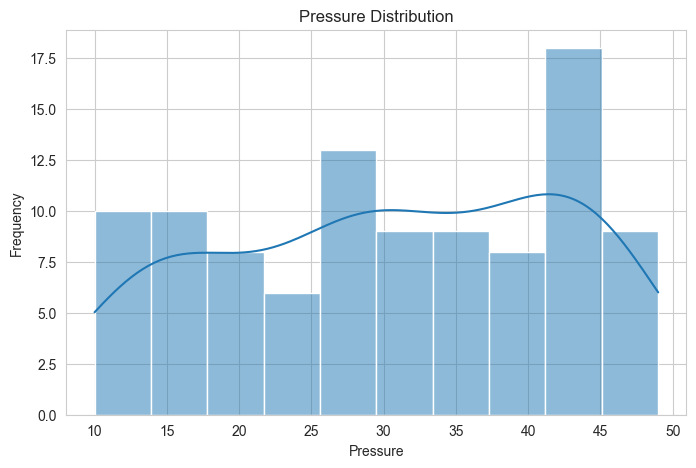

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Pressure'], bins=10, kde=True)

plt.title("Pressure Distribution")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.show()


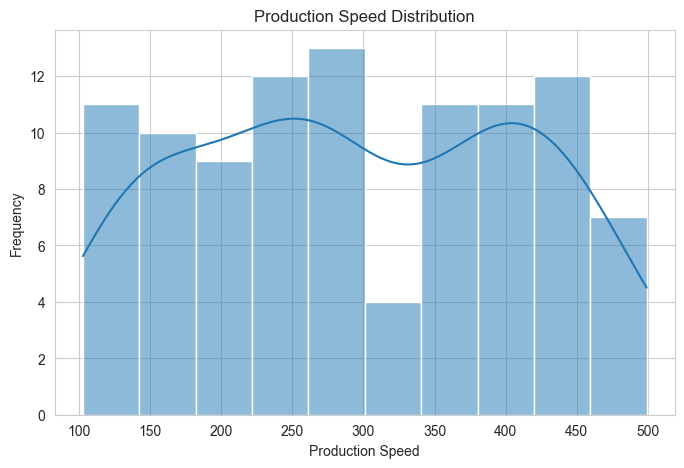

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Production_Speed'], bins=10, kde=True)

plt.title("Production Speed Distribution")
plt.xlabel("Production Speed")
plt.ylabel("Frequency")

plt.show()


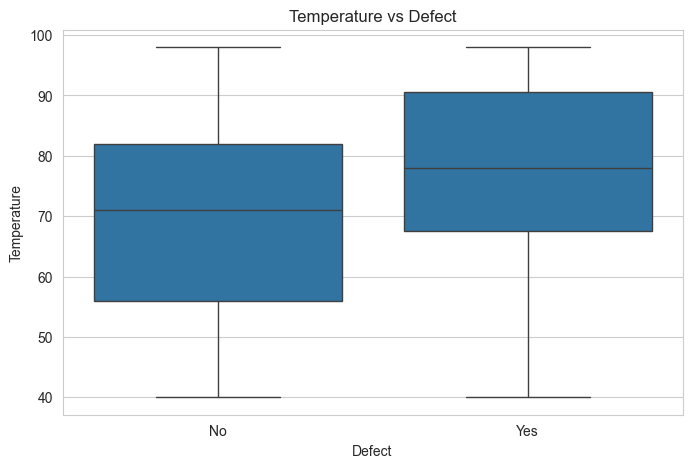

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Defect', y='Temperature', data=df)

plt.title("Temperature vs Defect")

plt.show()

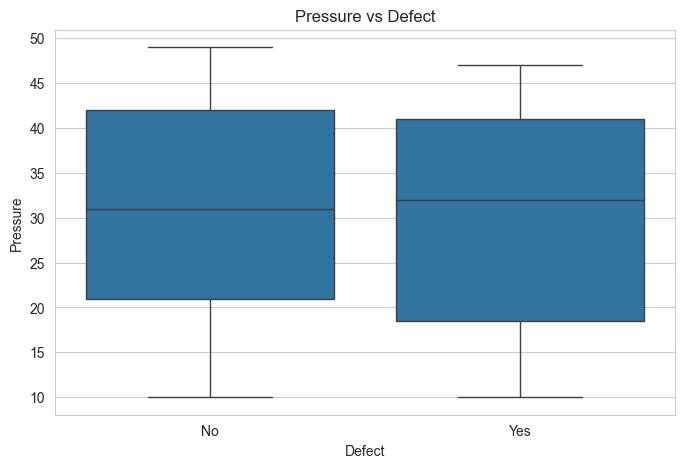

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Defect', y='Pressure', data=df)

plt.title("Pressure vs Defect")

plt.show()

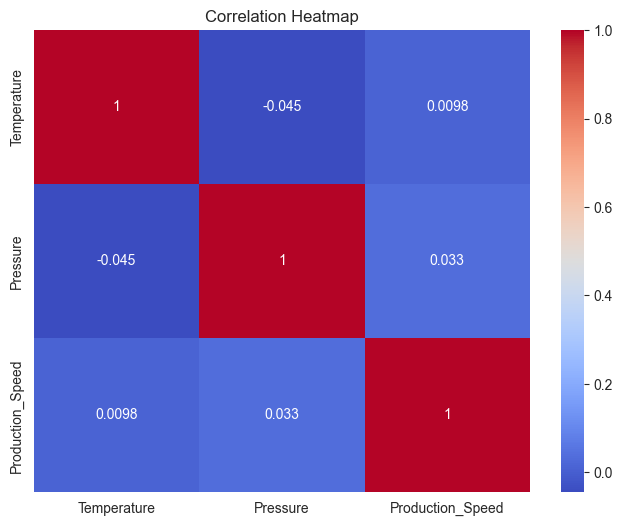

In [15]:
df['Temperature'] = pd.to_numeric(df['Temperature'])
df['Pressure'] = pd.to_numeric(df['Pressure'])
df['Production_Speed'] = pd.to_numeric(df['Production_Speed'])
numeric_df = df[['Temperature', 'Pressure', 'Production_Speed']]
plt.figure(figsize=(8,6))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()

In [16]:
defect_percent = (
    df['Defect']
    .value_counts(normalize=True) * 100
)

print("\n================ DEFECT PERCENTAGE ================\n")
print(defect_percent)


================ DEFECT PERCENTAGE ================

Defect
No     69.0
Yes    31.0
Name: proportion, dtype: float64


In [17]:
print("\n================ BUSINESS INSIGHTS ================\n")

most_defective_machine = (
    df[df['Defect'] == 'Yes']['Machine']
    .value_counts()
    .idxmax()
)

print(f"Machine with highest defects: {most_defective_machine}")

avg_temp = df['Temperature'].mean()

print(f"Average Temperature: {avg_temp:.2f}")

avg_pressure = df['Pressure'].mean()

print(f"Average Pressure: {avg_pressure:.2f}")



================ BUSINESS INSIGHTS ================

Machine with highest defects: M4
Average Temperature: 71.51
Average Pressure: 30.64


In [18]:
df.to_csv("cleaned_manufacturing_data.csv", index=False)

print("\nCleaned Dataset Saved Successfully!")


Cleaned Dataset Saved Successfully!
